In [ ]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.cm as cm
from matplotlib import colors
from utils import DEFAULT_FIG_DIR, plot_transient_hydraulic_heads_at_timestep
from hydraulic_tomography import ht_transient, hydraulic_tomography
from RGA import *
from gwsolver import *
#make a gif based on the saved images
import imageio
import time
print(DEFAULT_FIG_DIR)

In [ ]:
# numerical domain/mesh: regular grid
nx = 64
ny = 64

# random field properties
sigma = 1.0 # standard deviation
lx, ly = 0.15, 0.2 # correlation length (to numerical domain length)
mu = -2 # mean of the random field
k = 50 # number of retained principal components

# Generate synthetic field
K, alpha, V, beta = generate_synthetic_field(
    nx, ny,
    k=k,
    mu=mu,
NR=400,
    cov_type='gaussian',
    variance=sigma**2,
    lx=lx,
    ly=ly
)

# Prepare physical domain and well configuration

well_nodes, Q, dx, dy = prepare_physical_domain(nx, ny, Lox=320, Loy=320, q_original= -0.02 * (64/nx)**2)

# Solve hydraulic tomography
t0 = time.time()
hydraulic_heads = hydraulic_tomography(K, well_nodes, Q)
print("Elapsed time for solving HT:", time.time() - t0)

# Prepare observations
y0 = observation_operator(hydraulic_heads, well_nodes)

# Add measurement noise
y_obs, obv_error = add_noise(y0, noise_level=0.05)

# Save true values to json before optimization
initial_history = {
    'true_alpha': alpha,
    'true_mu': mu,
    'y_obs': y_obs,
    'alpha': [],
    'mu': [],
    'loss': [],
    'lambda': [],
    'step_norm': [],
    'time': [],
    'yp': []
}

# Optimization
b, opt_history = gauss_newton_dynamic_lambda(
    lambda b: forward_model(b, V.T, Q, well_nodes),
    b0=np.concatenate((np.zeros(k), np.array([beta]))),
    y_obs=y_obs,
    lam_init=1e-3,
    max_iter=10,
    tol=1e-5,
    history=initial_history,
    adaptive_lambda=False,
    anneal_lambda=True,
    min_lambda=1e-5,
    json_file='steady_state_history.json',
)



Elapsed time for solving HT: 0.08198785781860352
Iter  Lambda      Loss           Step Norm      Time (s)  
------------------------------------------------------------
1     1.00e-03    7.703006e+00   3.675402e+00   3.325     
2     1.00e-03    6.737155e+00   1.433619e-01   3.543     
3     1.00e-03    6.706586e+00   4.558156e-03   3.580     
4     1.21e-05    1.577710e+02   6.967821e-01   3.381     
5     1.21e-05    1.185241e+02   3.311297e-01   3.887     
6     1.21e-05    1.169432e+02   1.351887e-02   4.556     
7     1.00e-05    1.382464e+02   8.481765e-04   4.198     
8     1.00e-05    1.382442e+02   1.595268e-05   4.066     
9     1.00e-05    1.382441e+02   5.284531e-07   4.079     
✅ Converged.


Conductivity Field Metrics:
L2 relative error: 0.14474964290030667
Accuracy: 0.920166015625
Heads Metrics:
MAE: 0.1425613890403947 m
RMSE: 0.23502153150909072 m
MSE: 0.055235120272878524 m^2
L2 relative error: 0.047891280002994537
Heads Metrics:
MAE: 0.14250416931511153 m
RMSE: 0.18976506653925496 m
MSE: 0.036010780478647864 m^2
L2 relative error: 0.04971352264184945


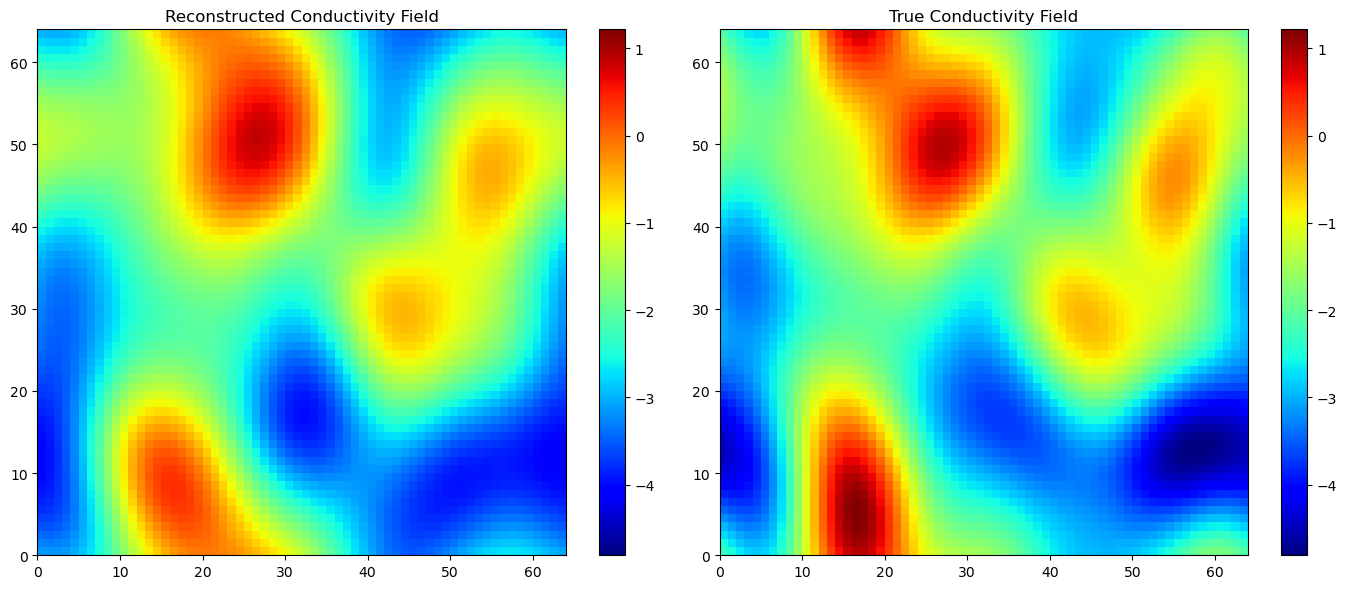

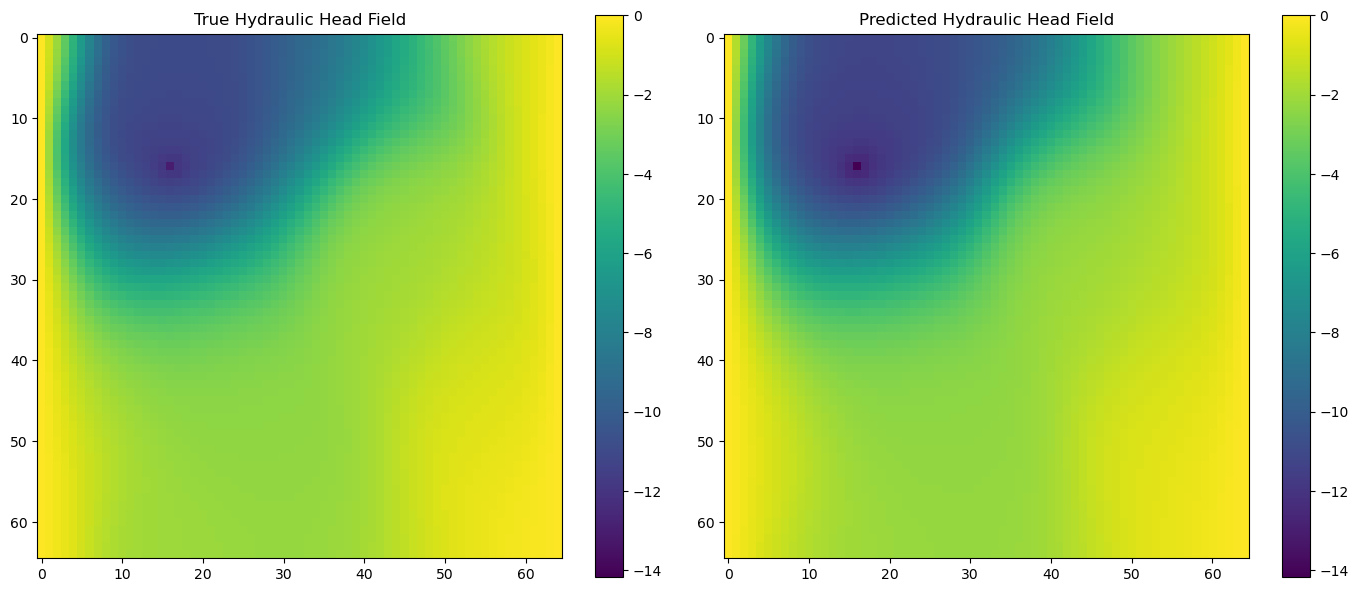

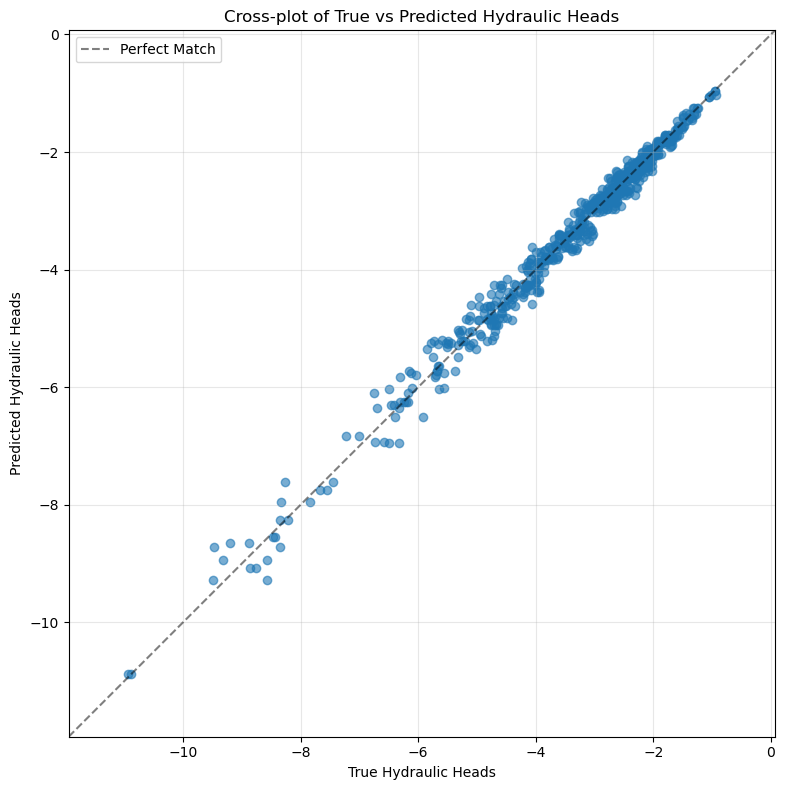

In [4]:
# # Load the optimization history
# history = load_history('steady_state_history.json')

# # Extract the true and predicted alpha
# predicted_alpha = history['alpha'][-1]
# predicted_mu = history['mu'][-1]

# # Extract the true alpha
# true_alpha = history['true_alpha']
# true_mu = history['true_mu']

predicted_alpha, predicted_mu = b[:k], b[k]
true_alpha, true_mu = alpha, mu

# Reconstruct the field
reconstructed_field = np.squeeze(V.T @ predicted_alpha[:, np.newaxis],axis=1) + predicted_mu
true_field = np.squeeze(V.T @ true_alpha[:, np.newaxis]) + true_mu

# Compute the conductivity metrics
conductivity_metrics(true_field, reconstructed_field)

# Plot the solution
fig1 = plot_conductivity_fields(reconstructed_field, true_field, nx, ny)

# compute the head fields
true_head_field = hydraulic_tomography(np.exp(true_field), well_nodes, Q)
predicted_head_field = hydraulic_tomography(np.exp(reconstructed_field), well_nodes, Q)

# Plot the head fields
pump_id = 0 # 0, 1, 2, 3, 4 
fig3 = plot_head_fields(true_head_field[pump_id].reshape((nx+1, ny+1)), predicted_head_field[pump_id].reshape((nx+1, ny+1)))

# compute the head metrics
mae, rmse, mse, l2_relative_error = head_metrics(true_head_field[pump_id], predicted_head_field[pump_id])

# Extract the true and predicted heads
true_heads = history['y_obs']
predicted_heads = observation_operator(predicted_head_field, well_nodes)
mae, rmse, mse, l2_relative_error = head_metrics(true_heads, predicted_heads)

# Plot the heads comparison
fig4 = plot_observations_vs_predictions(true_heads, predicted_heads)

In [5]:
initial_head = np.zeros(np.prod((nx+1, ny+1)))
t_max = 2.0
nt = 10
dt = t_max / nt

well_relative_locs = []
horizontal_locs = vertical_locs = [0.25, 0.375, 0.5, 0.625, 0.75]
for h in horizontal_locs:
    for v in vertical_locs:
        well_relative_locs.append((h, v))
well_nodes, Q, dx, dy = prepare_physical_domain(nx, ny, Lox=320, Loy=320, q_original= -0.02 * (64/nx)**2, well_relative_locs=well_relative_locs)

# Solve hydraulic tomography
t0 = time.time()
HT_transient_heads = ht_transient(K, well_nodes, Q, dt, t_max, initial_head)
print("Elapsed time for solving HT:", time.time() - t0)

Elapsed time for solving HT: 0.39277005195617676


In [ ]:
HT_transient_heads_4d = np.reshape(HT_transient_heads, (25, nt, nx+1, ny+1))

from IPython.display import Image, display
import io

for well_idx in range(HT_transient_heads_4d.shape[0]):
    images = []
    for i in range(nt):
        fig = plot_transient_hydraulic_heads_at_timestep(
            HT_transient_heads_4d[well_idx], 
            t_idx=i, 
            dt=dt, 
            hmin=HT_transient_heads_4d[well_idx].min()*0.7, 
            hmax=HT_transient_heads_4d[well_idx].max(), 
            nlvls=7, 
            cmp_str='viridis'
        )
        # Save figure to a buffer instead of disk
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100)
        buf.seek(0)
        images.append(imageio.imread(buf))
        plt.close(fig)
        buf.close()
    gif_path = f"{DEFAULT_FIG_DIR}/transient_heads_well{well_idx}.gif"
    imageio.mimsave(gif_path, images, duration=500)
    print(f"GIF for well {well_idx} saved to {gif_path}")
    # display(Image(filename=gif_path))


/tmp/ipykernel_15914/975497332.py:22: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(buf))


GIF for well 0 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well0.gif
GIF for well 1 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well1.gif
GIF for well 2 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well2.gif
GIF for well 3 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well3.gif
GIF for well 4 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well4.gif
GIF for well 5 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well5.gif
GIF for well 6 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well6.gif
GIF for well 7 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well7.gif
GIF for well 8 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well8.gif
GIF for well 9 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_heads_well9.gif
GIF for well 10 saved to /Users/guoquan/Desktop/code/pyRGA/figures/transient_hea

In [197]:
pump_id_list=[0, 1, 2, 3, 4]
y0 = transient_observation_operator(HT_transient_heads, well_nodes, pump_id_list=pump_id_list, timesteps=np.arange(0, 10, 1))
y_obs, obv_error = add_noise(y0, noise_level=0.05)
print(y0.shape)

(1200,)


In [202]:
# Save true values to json before optimization
initial_history = {
    'true_alpha': alpha,
    'true_mu': mu,
    'y_obs': y_obs,
    'alpha': [],
    'mu': [],
    'loss': [],
    'lambda': [],
    'step_norm': [],
    'time': [],
    'yp': []
}

# Optimization
partial_well_nodes = [well_nodes[idx] for idx in pump_id_list]
b, opt_history = gauss_newton_dynamic_lambda(
    lambda b: transient_forward_model(b, V.T, Q, partial_well_nodes, well_nodes, dt, t_max, [], [], initial_head),
    b0=np.concatenate((np.zeros(k), np.array([beta]))),
    y_obs=y_obs,
    lam_init=1e-3,
    max_iter=10,
    tol=1e-5,
    history=initial_history,
    adaptive_lambda=False,
    anneal_lambda=True,
    min_lambda=1e-5
)

Iter  Lambda      Loss           Step Norm      Time (s)  
------------------------------------------------------------
1     1.00e-03    3.163062e+00   4.841481e+00   51.920    
2     1.00e-03    2.826074e+00   1.192422e-01   54.882    
3     1.00e-03    2.825869e+00   7.262815e-05   60.393    
4     1.00e-05    1.286318e+02   5.623717e-01   53.571    
5     1.00e-05    1.272812e+02   1.061165e-02   62.184    
6     1.00e-05    1.272788e+02   1.885112e-05   55.102    
7     1.00e-05    1.272787e+02   8.528869e-07   55.681    
✅ Converged.


In [219]:
import io
reconstructed_fields = []
for i, (alpha, mu) in enumerate(zip(opt_history['alpha'], opt_history['mu'])):
    if i < 5:
        reconstructed_field = (V.T @ alpha[:, np.newaxis]).squeeze() + mu
        reconstructed_fields.append(reconstructed_field.copy())
    if i == 3 and len(reconstructed_fields) > 3 and len(reconstructed_fields) > 2:
        avg_field = 0.5 * reconstructed_fields[3] + 0.5 * reconstructed_fields[2]
        # Plot the averaged reconstructed field
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.pcolormesh(avg_field.reshape((nx, ny)), cmap='jet')
        fig.colorbar(im, ax=ax)
        ax.set_title('Averaged Reconstructed Conductivity Field')
        plt.tight_layout()
        fig_path = f"{DEFAULT_FIG_DIR}/avg_reconstructed_field_2_3.png"
        fig.savefig(fig_path, dpi=100)
        plt.close(fig)
        # np.save(f"{DEFAULT_FIG_DIR}/avg_reconstructed_field_2_3.npy", avg_field)

Iter  Lambda      Loss           Step Norm      Time (s)  
------------------------------------------------------------
1     1.00e-03    2.350486e+00   3.350964e+00   14.480    
2     1.00e-03    1.301420e+00   8.060937e-01   17.286    
3     1.00e-03    1.298516e+00   2.236299e-03   13.723    
4     1.00e-05    4.435699e+01   5.216772e-01   13.337    
5     1.00e-05    4.420326e+01   3.477599e-03   13.211    
6     1.00e-05    4.420320e+01   1.549160e-06   14.237    
✅ Converged.


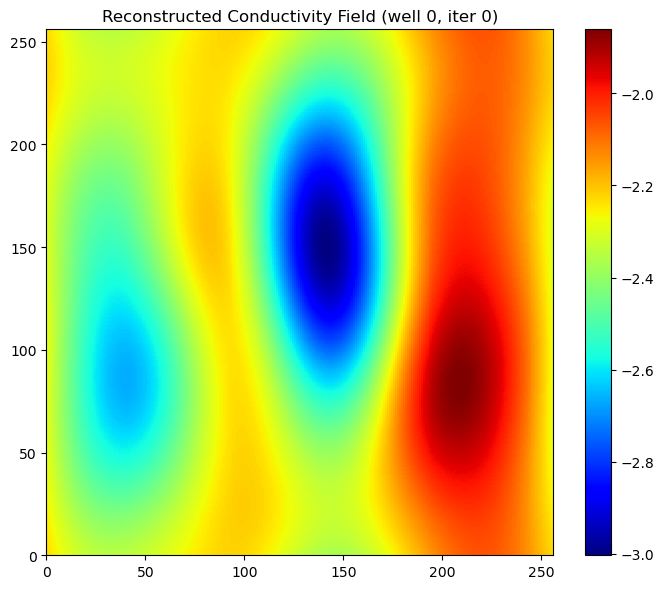

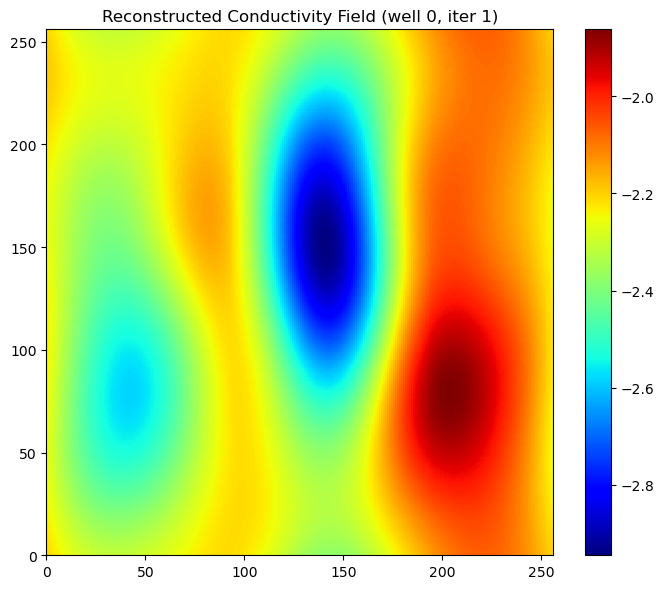

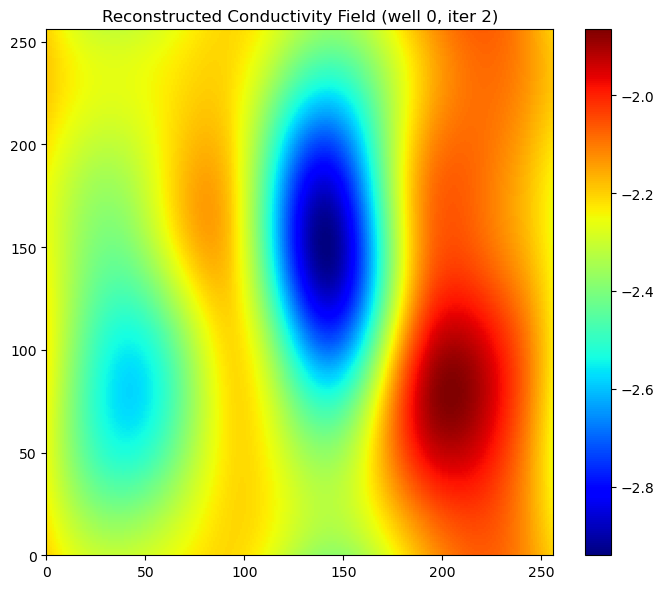

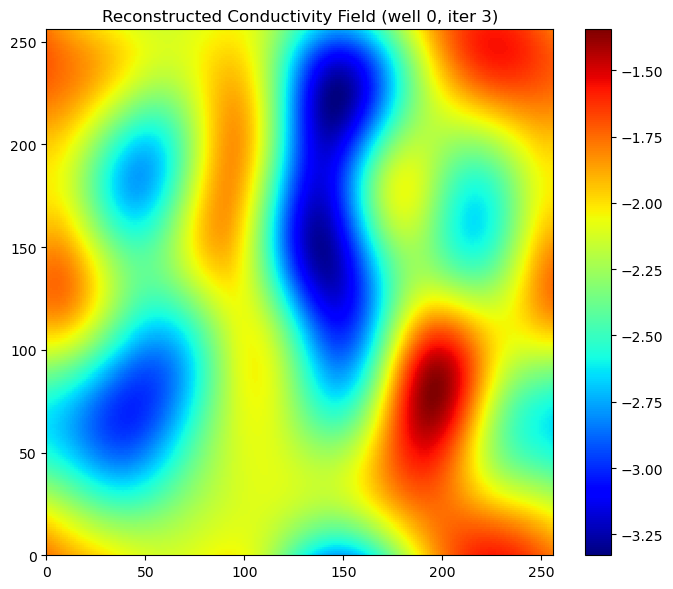

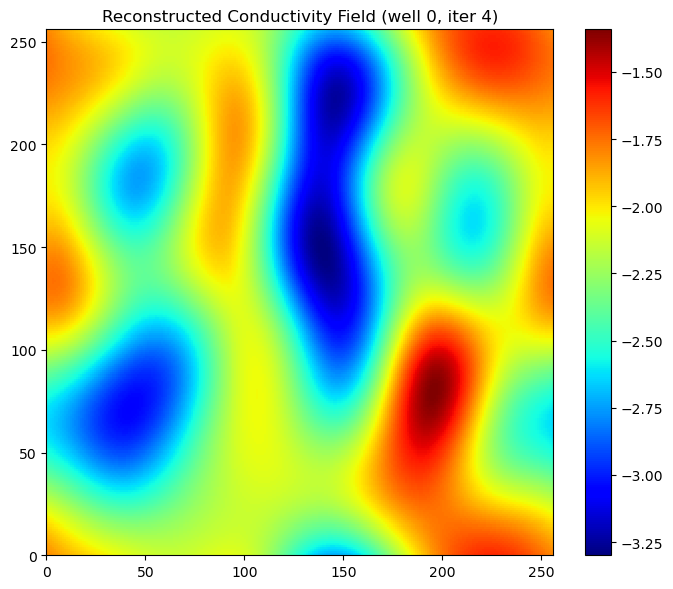

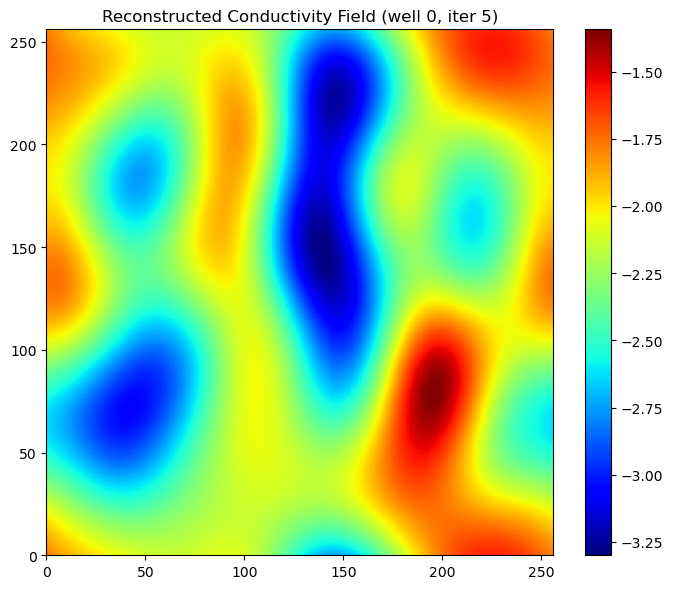

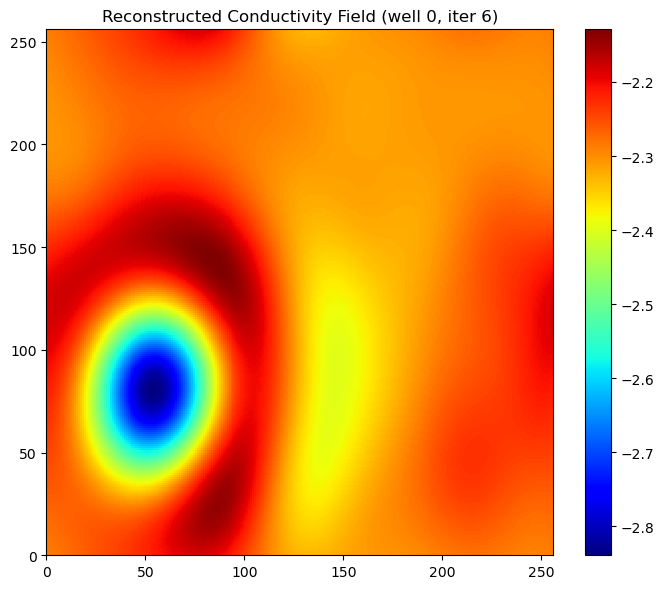

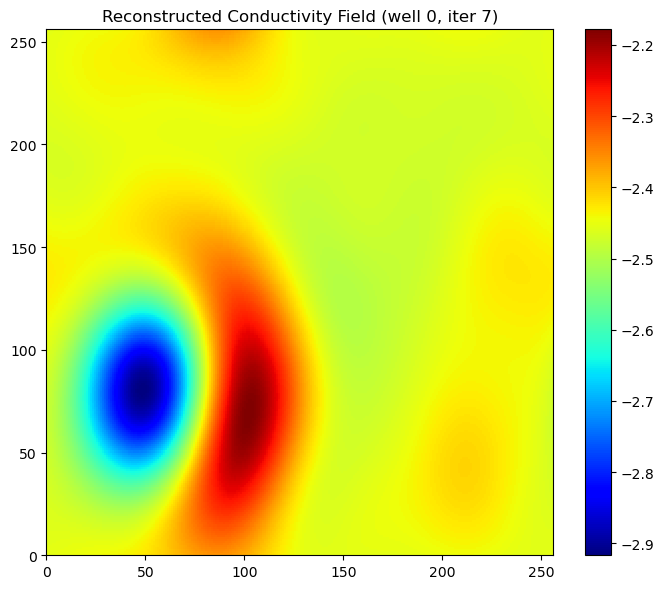

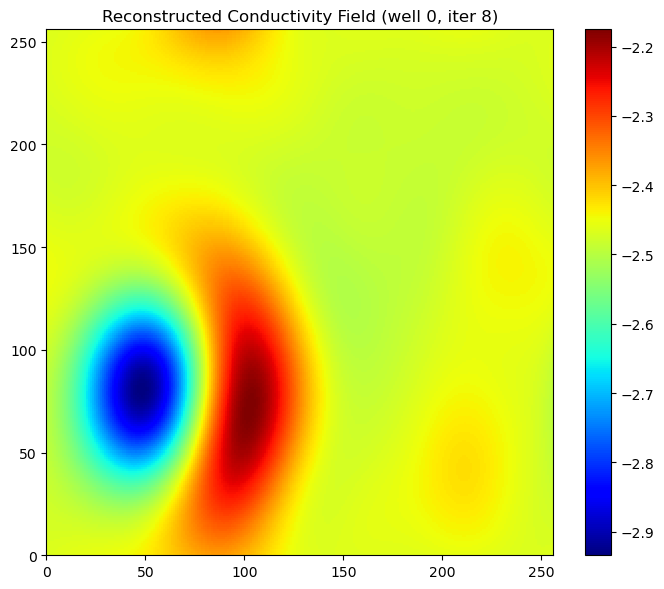

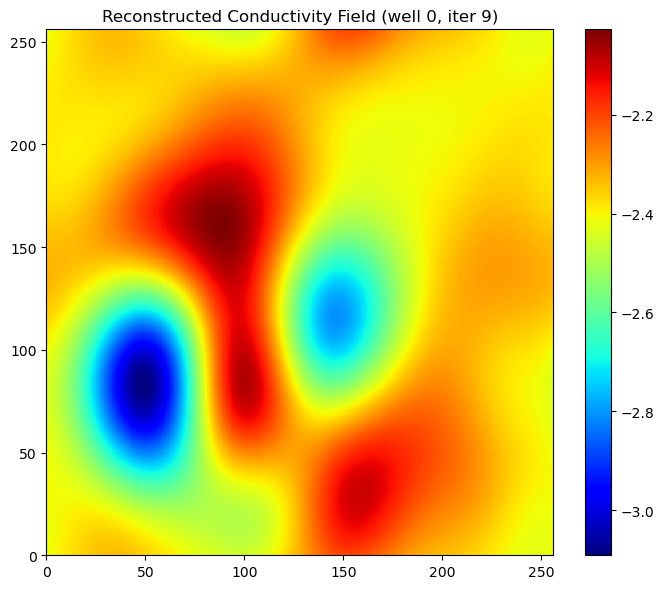

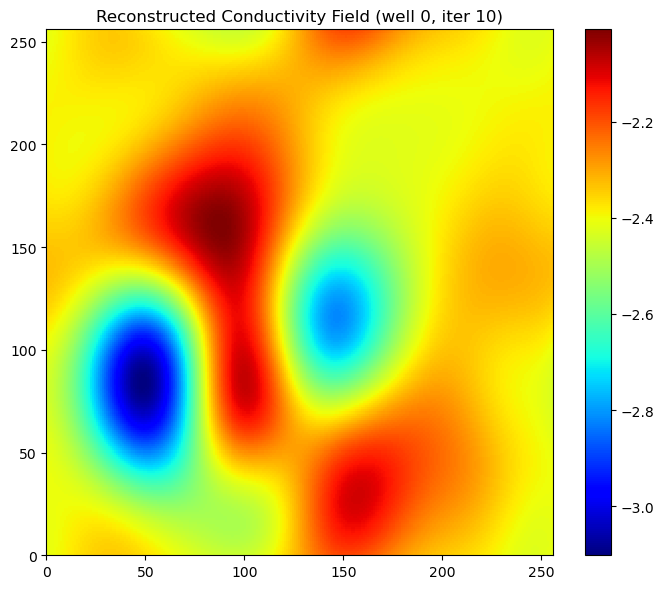

Iter  Lambda      Loss           Step Norm      Time (s)  
------------------------------------------------------------
1     1.00e-03    1.216305e+04   6.181970e+00   18.439    
2     1.00e-03    1.663678e+03   6.310943e+00   15.765    
3     1.00e-03    2.648630e+02   5.281276e+00   13.506    
4     3.90e-02    6.538930e+00   2.677517e+00   13.596    
5     3.90e-02    6.289861e+00   3.959853e-02   13.147    
6     3.90e-02    6.271285e+00   2.962015e-03   13.775    
7     2.04e-02    1.094133e+01   3.752528e-02   13.466    
8     2.04e-02    1.090227e+01   3.582446e-03   14.874    
9     2.04e-02    1.089776e+01   4.142523e-04   13.886    
10    1.41e-02    1.450270e+01   2.122835e-02   13.261    


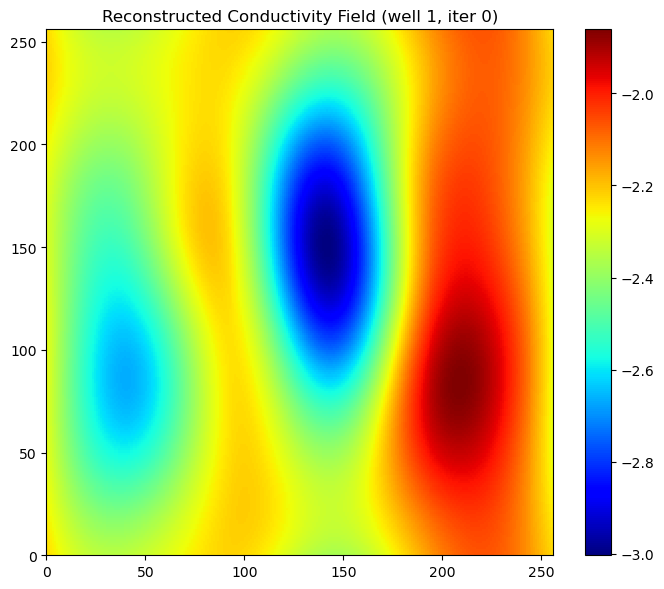

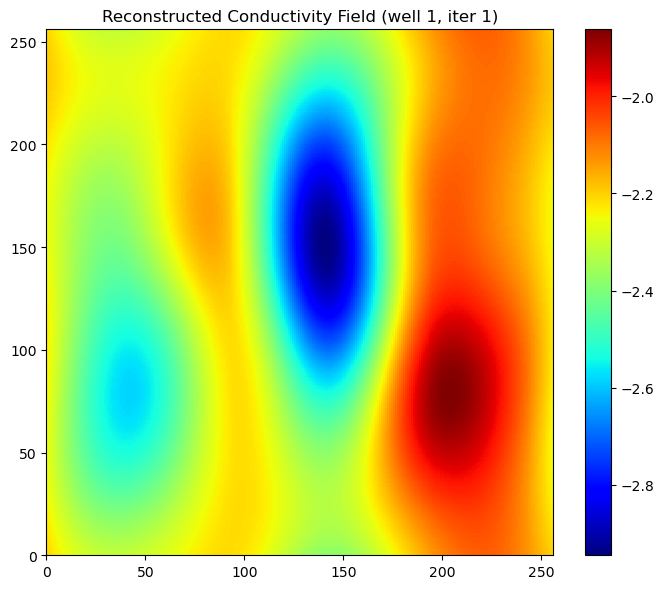

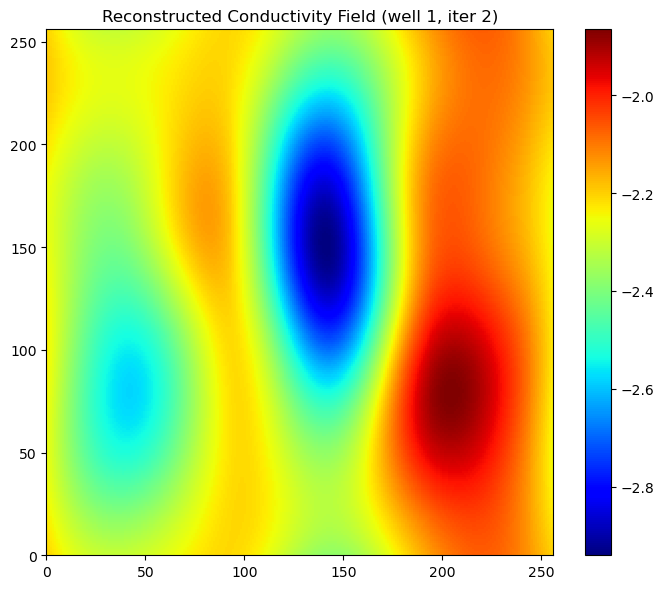

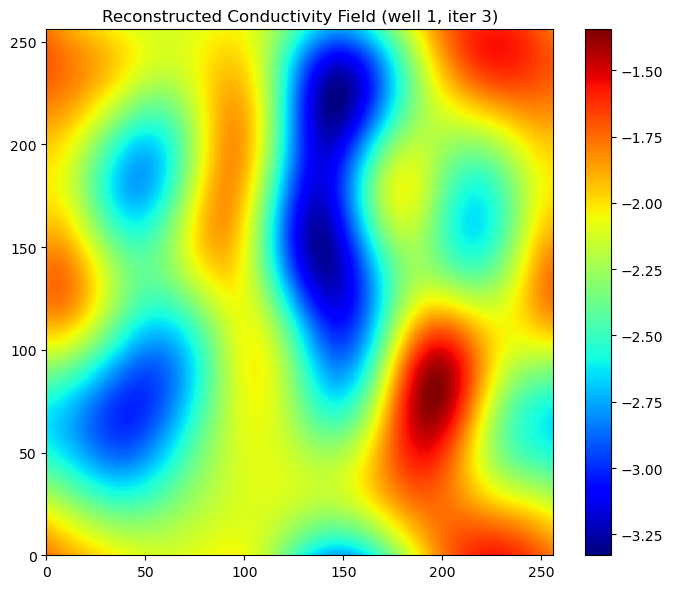

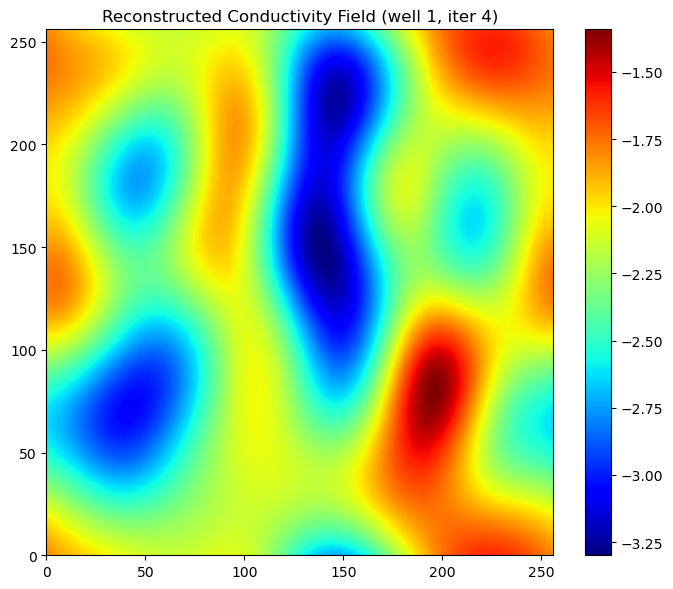

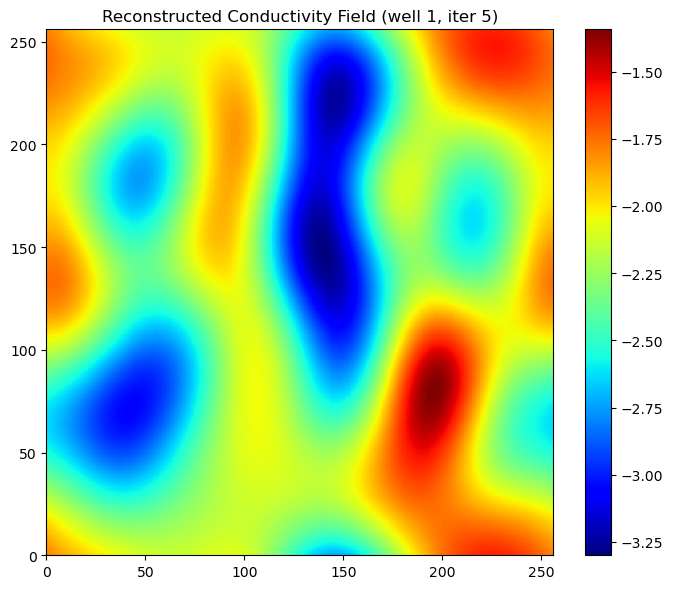

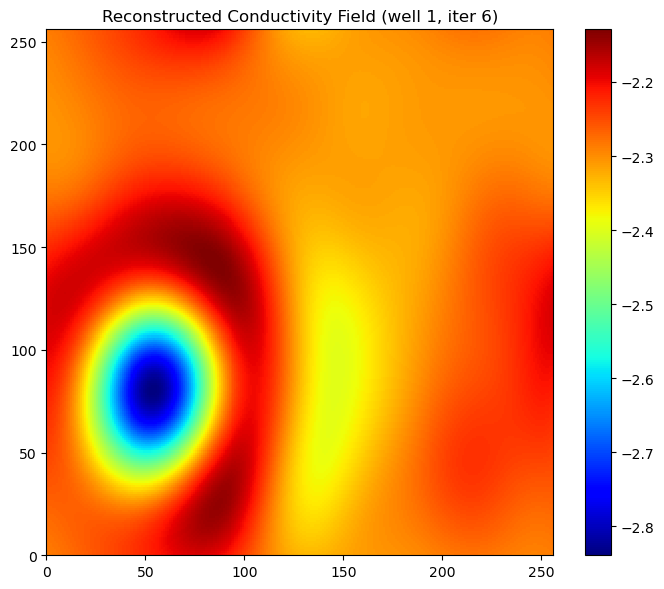

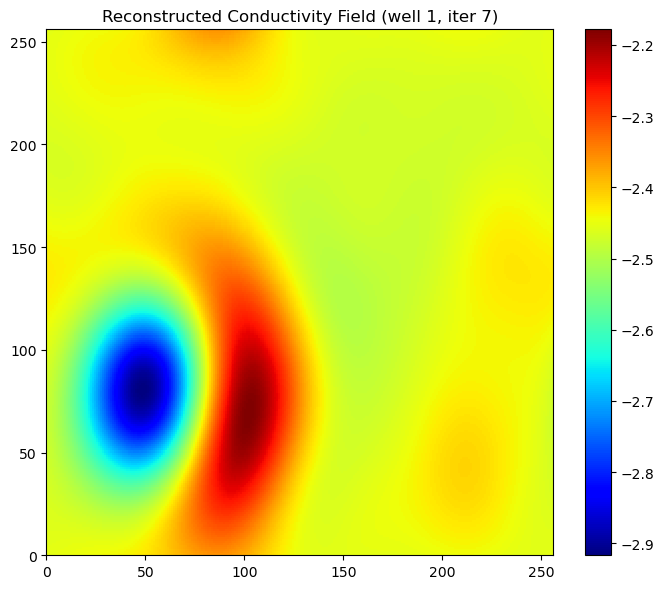

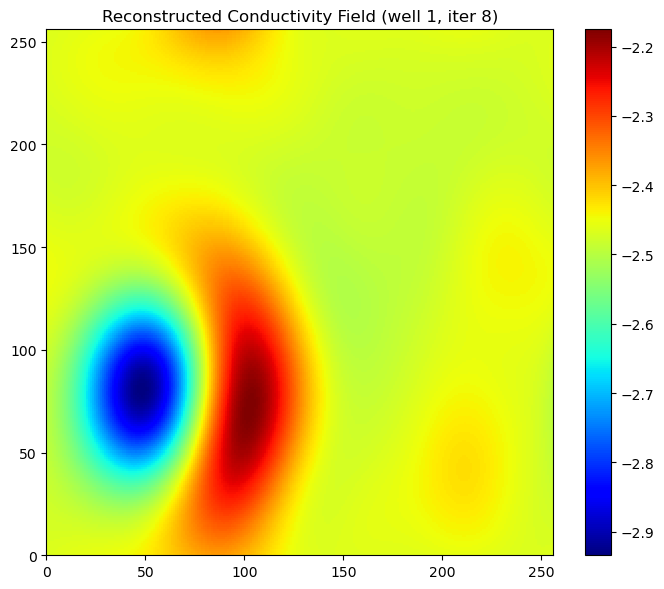

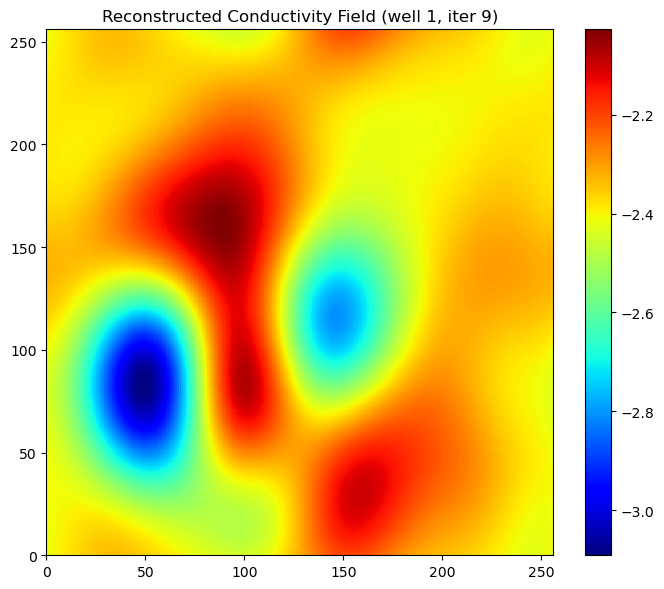

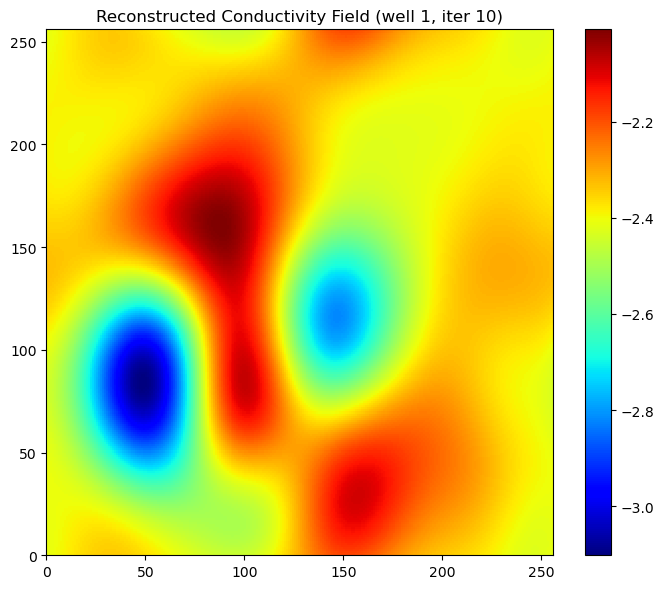

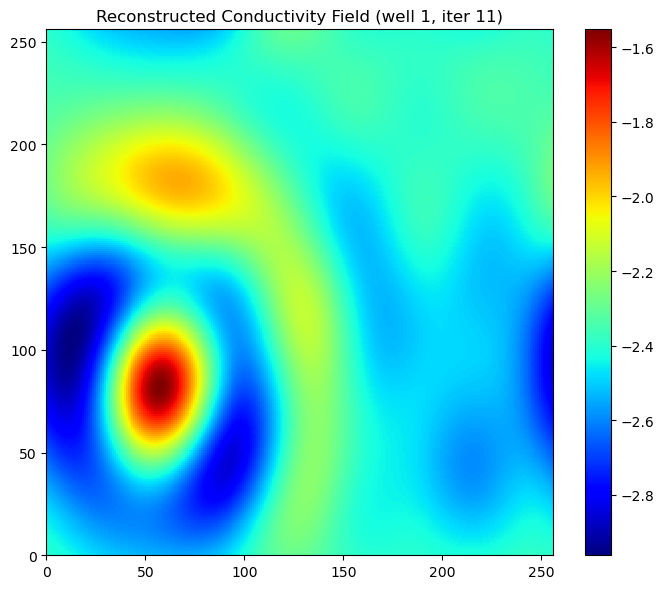

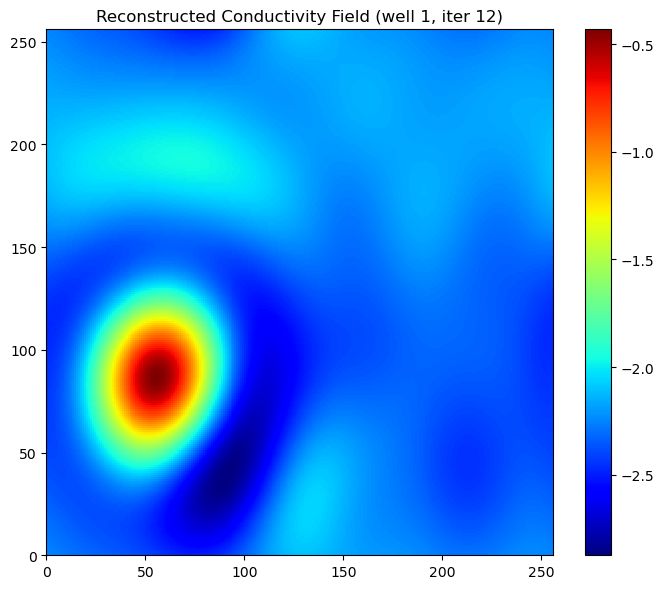

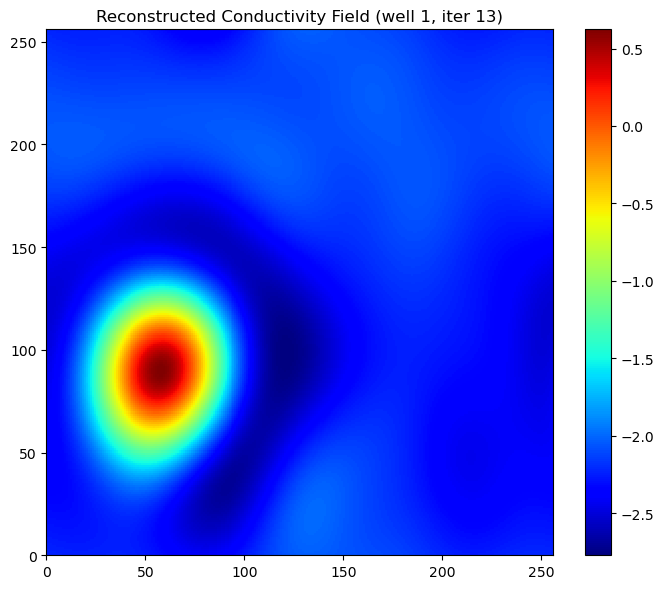

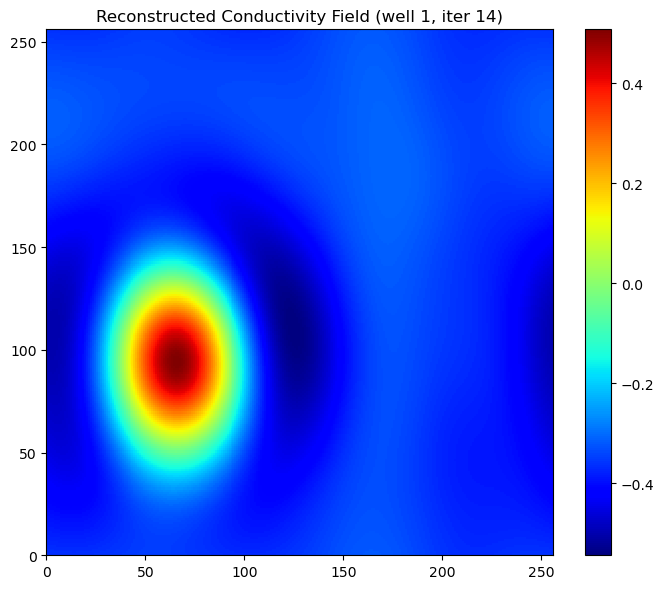

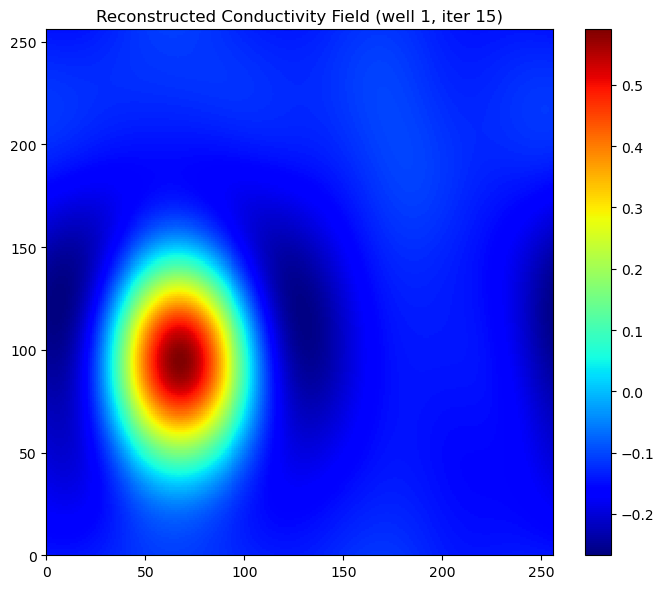

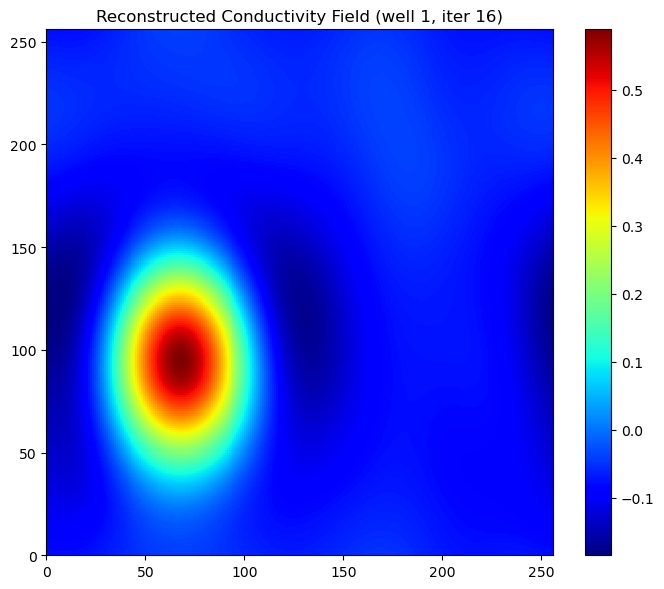

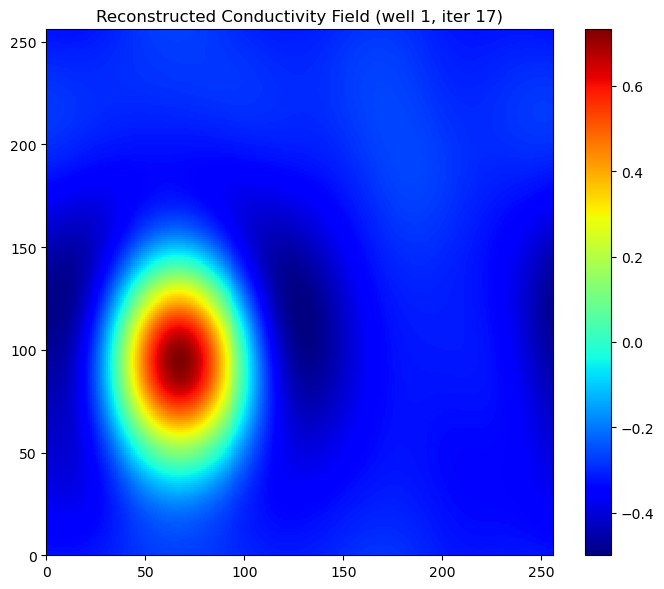

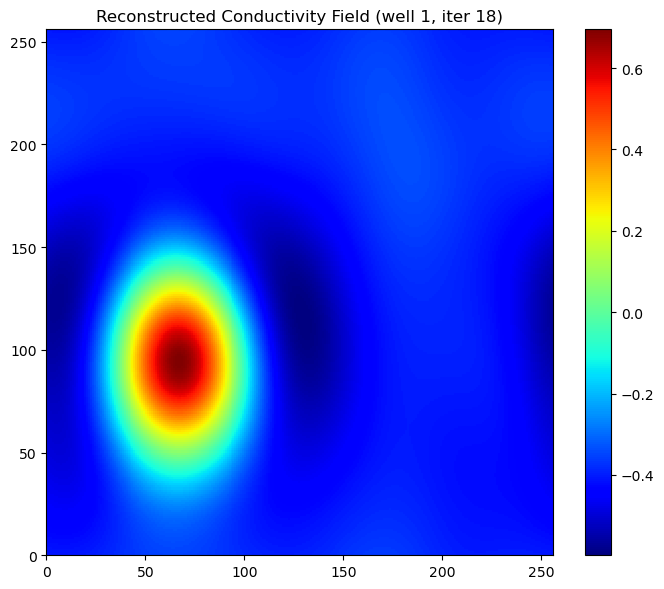

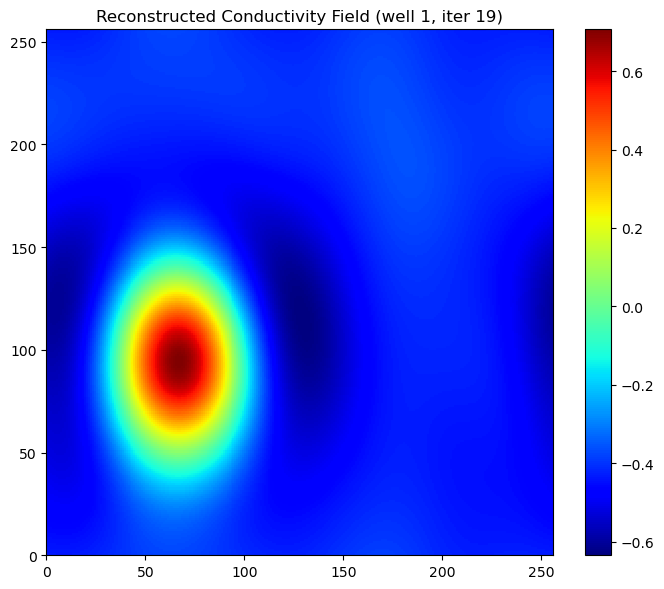

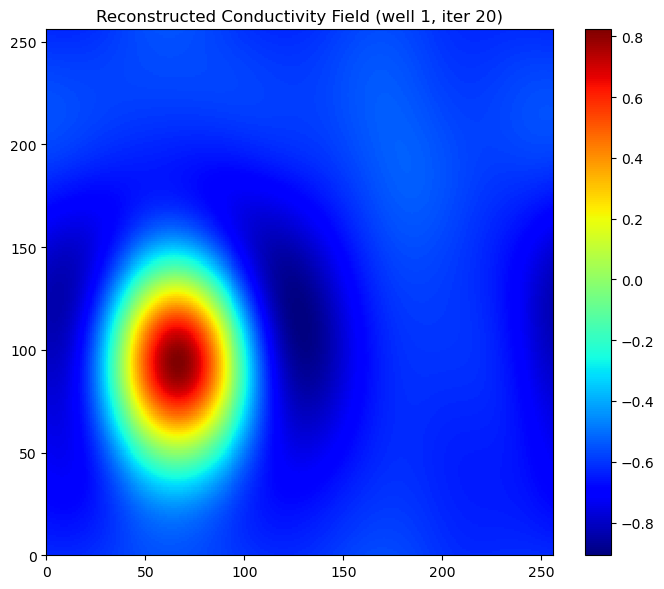

Iter  Lambda      Loss           Step Norm      Time (s)  
------------------------------------------------------------
1     1.00e-03    1.329043e+02   1.091355e+00   15.240    
2     1.00e-03    1.225683e+02   8.432888e-02   18.150    
3     1.00e-03    1.221673e+02   3.282351e-03   19.892    
4     8.48e-04    1.396606e+02   1.897214e-03   16.293    
5     8.48e-04    1.396185e+02   3.014532e-04   21.478    
6     8.48e-04    1.396012e+02   1.237568e-04   18.353    
7     8.24e-04    1.428159e+02   4.118984e-05   17.826    
8     8.24e-04    1.428152e+02   5.223172e-06   21.400    
✅ Converged.


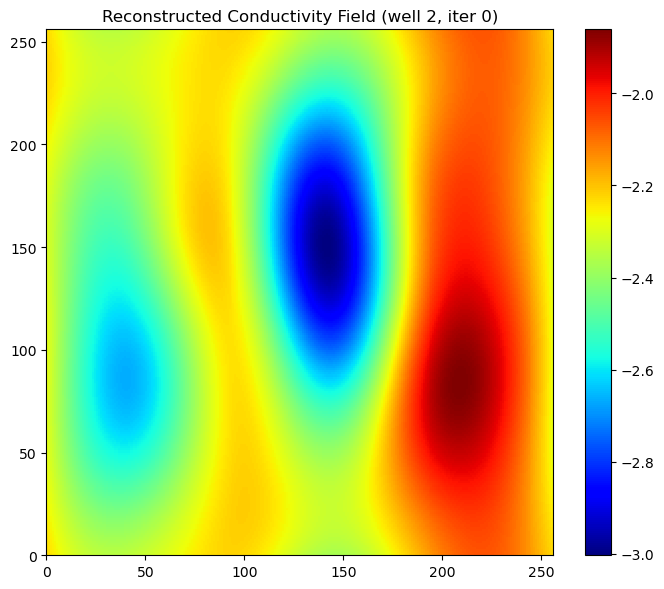

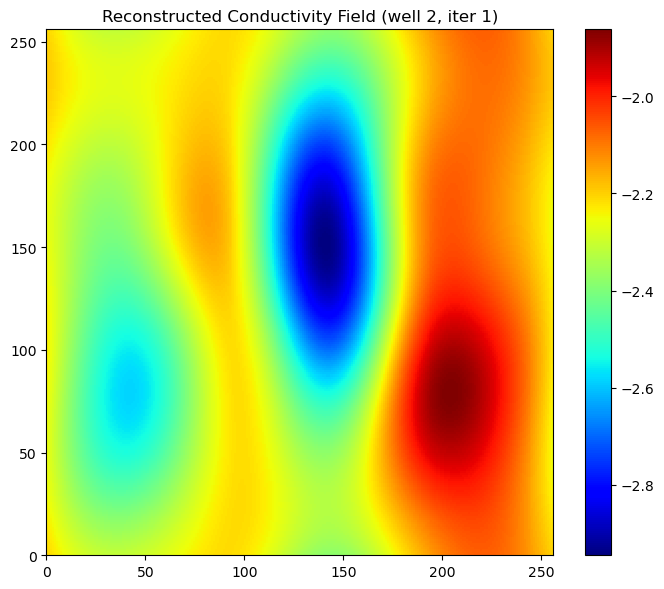

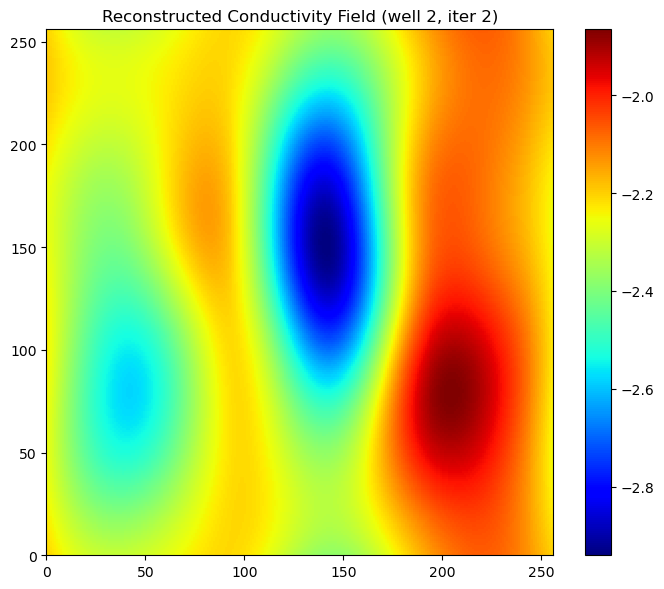

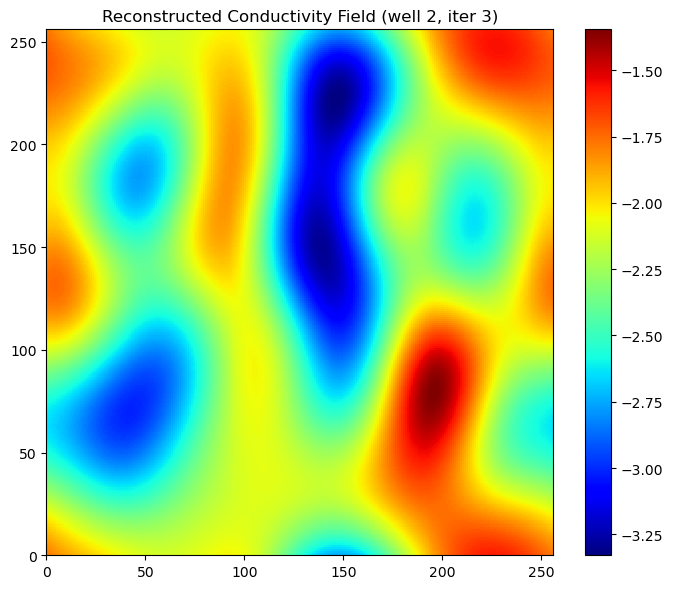

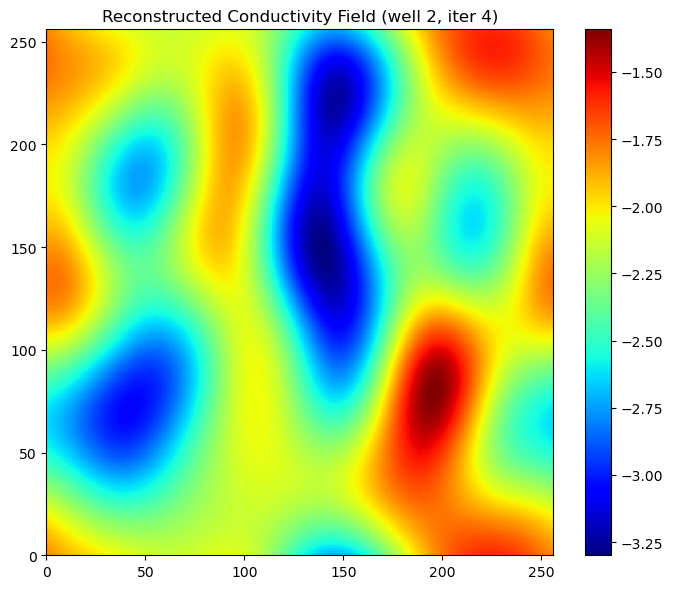

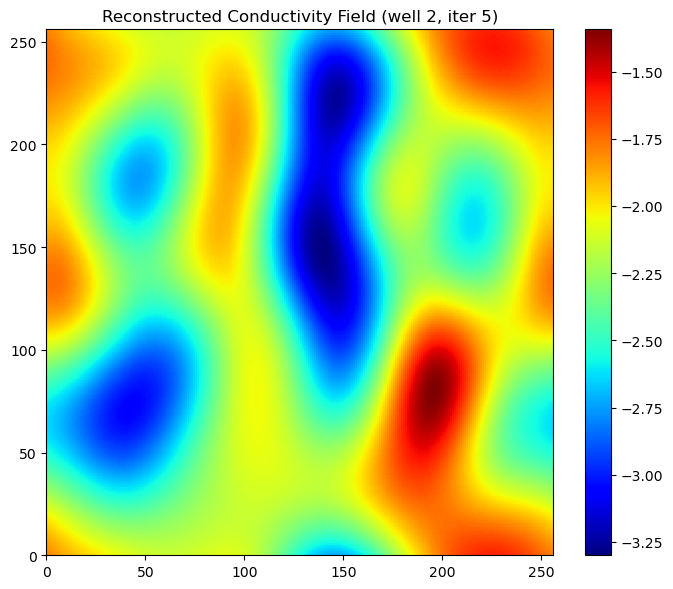

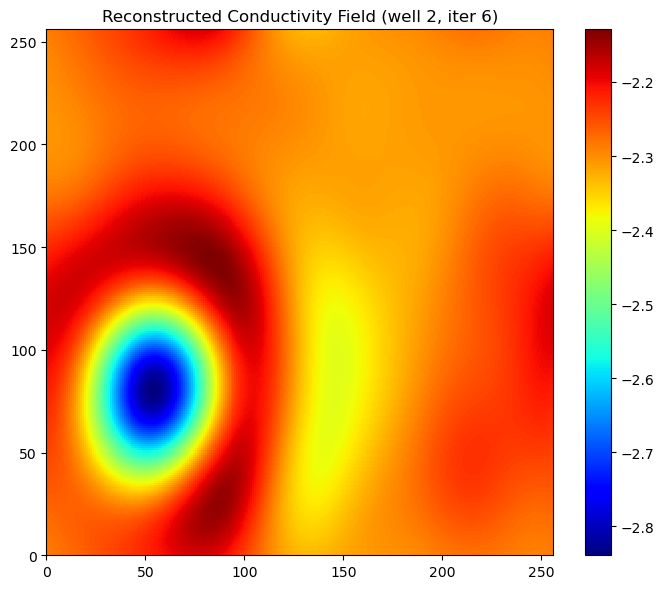

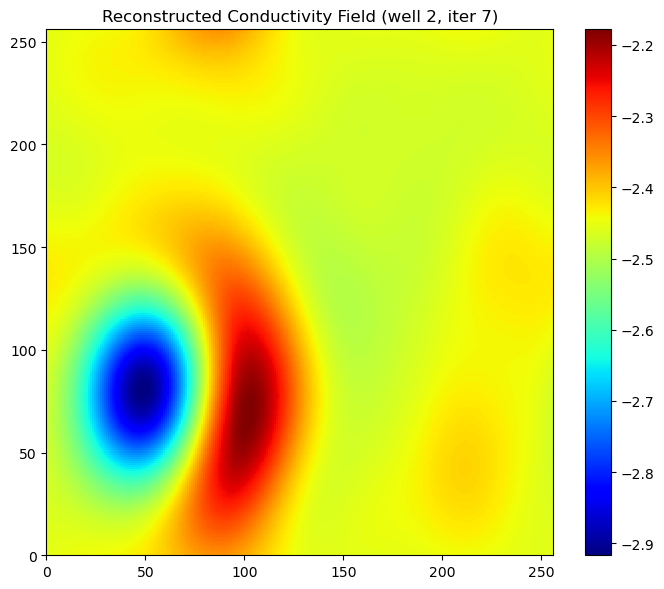

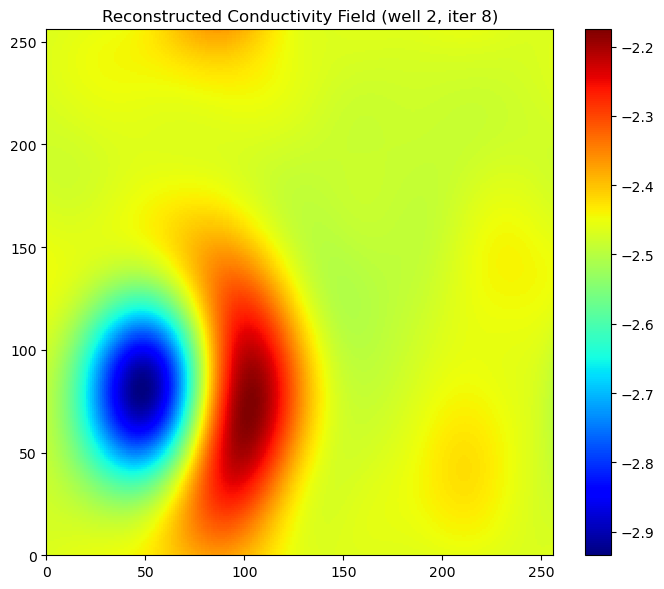

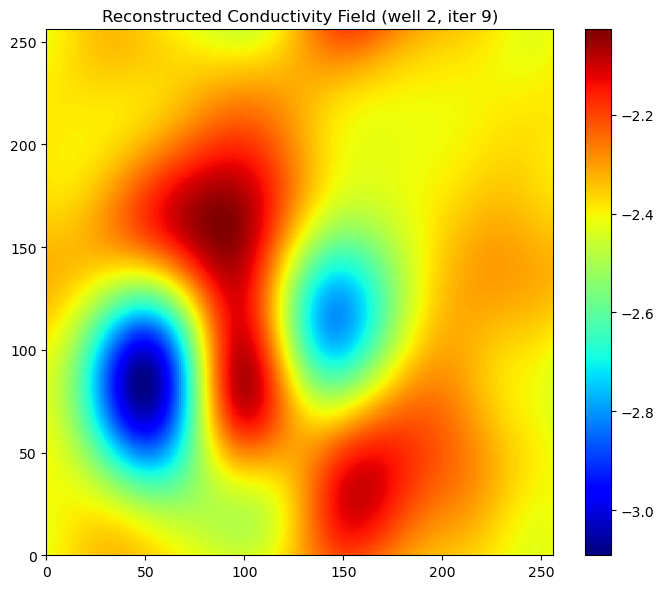

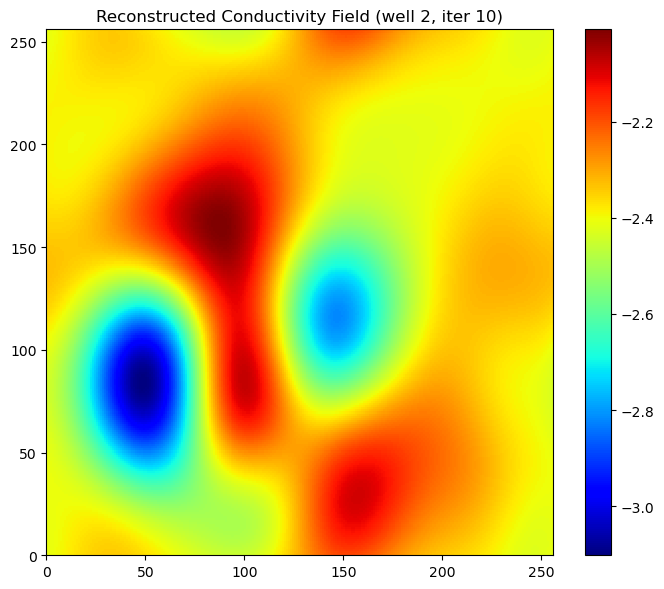

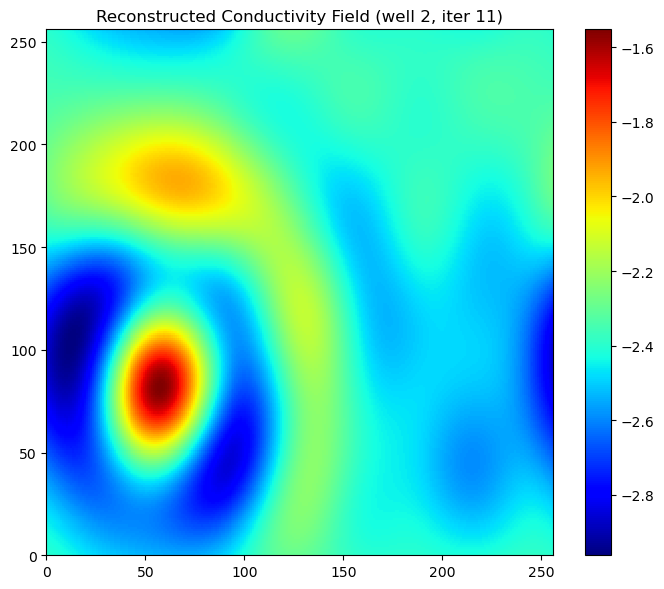

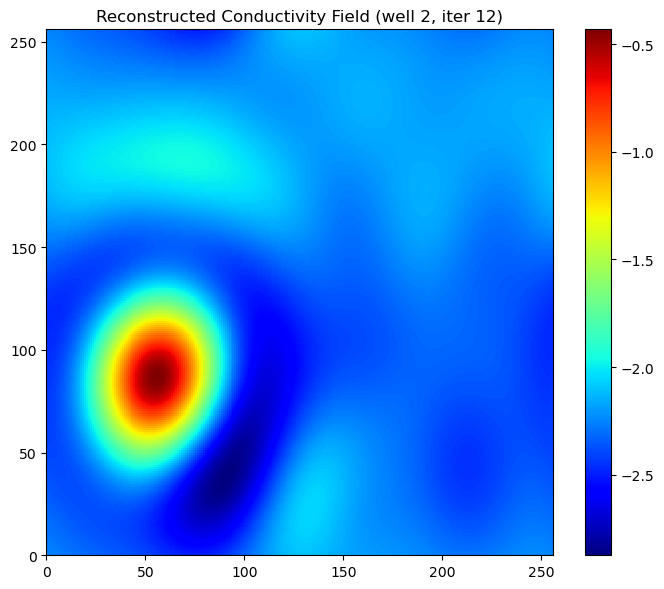

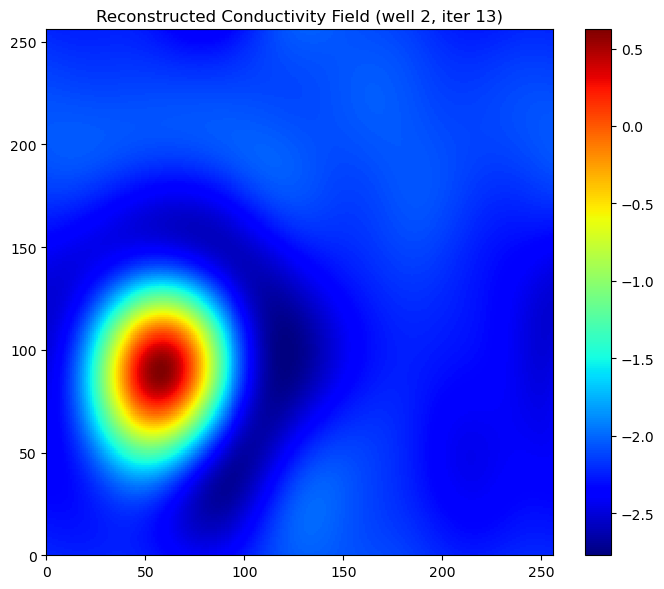

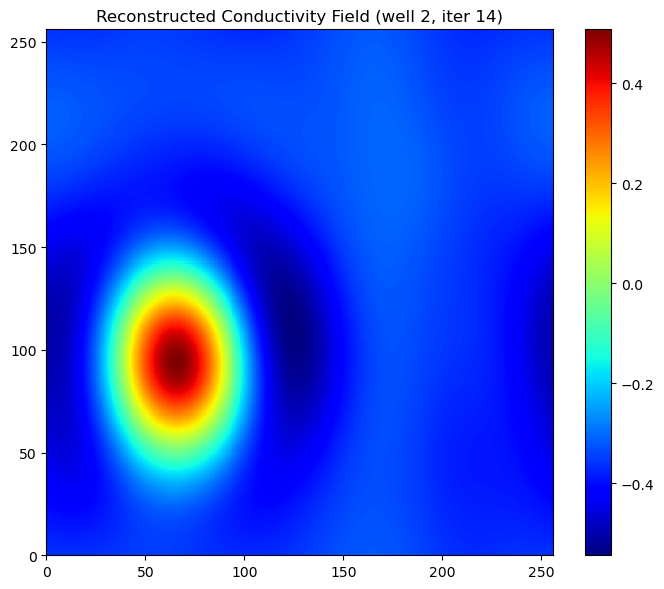

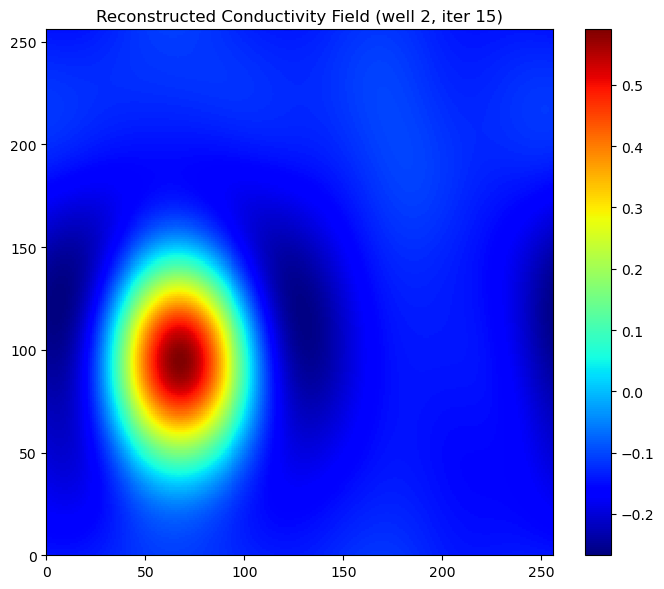

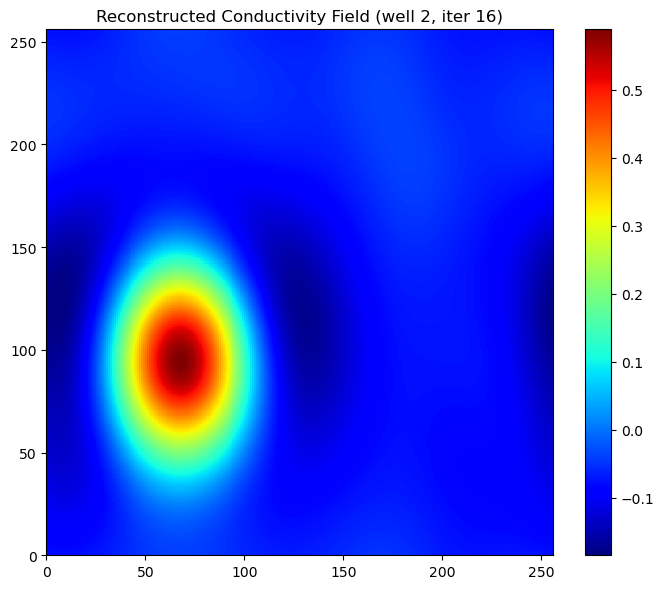

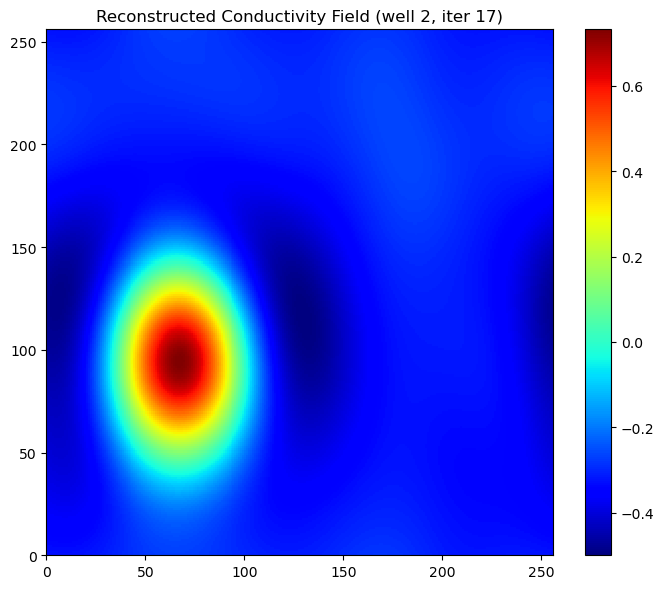

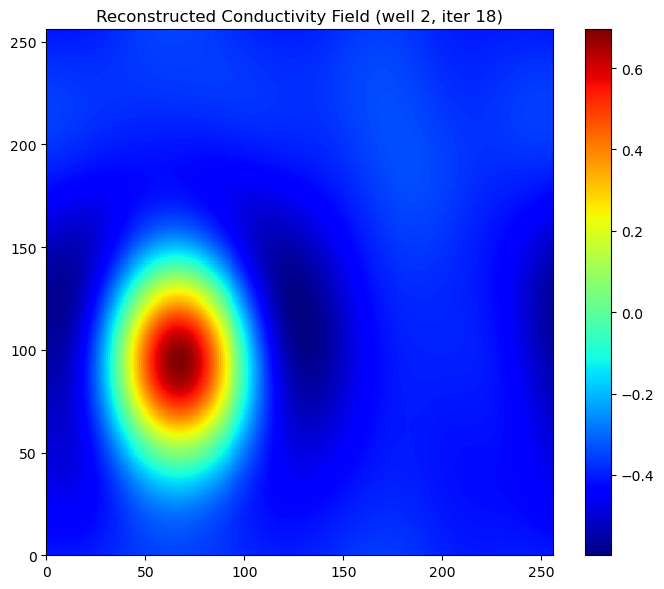

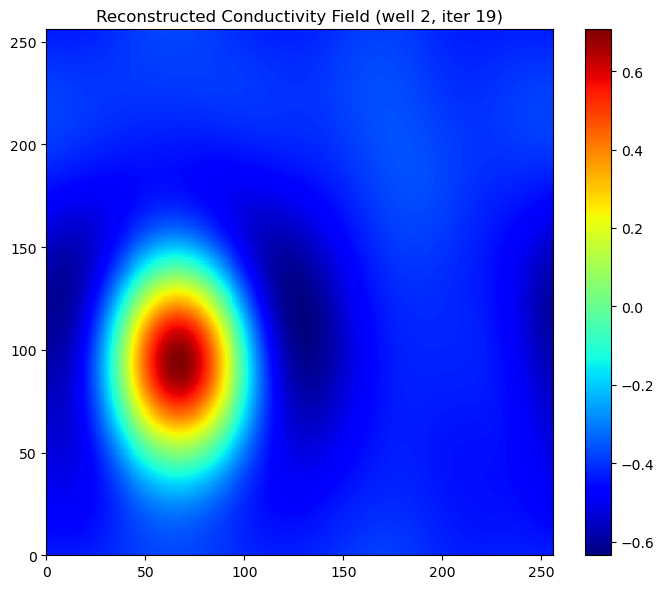

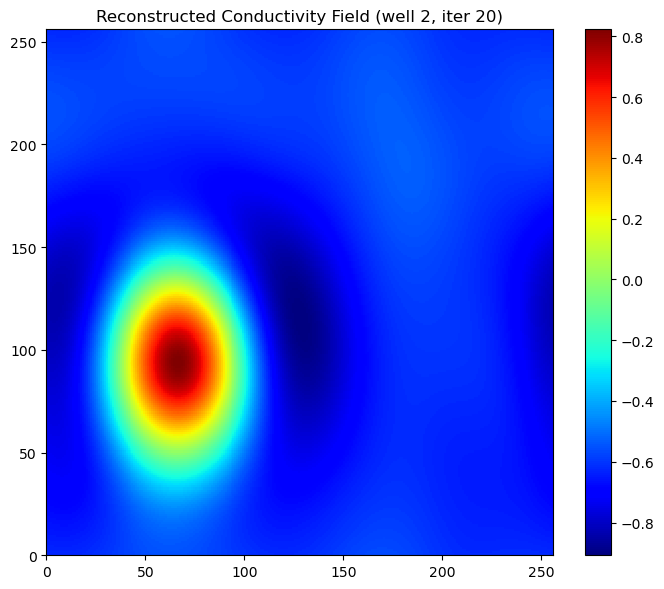

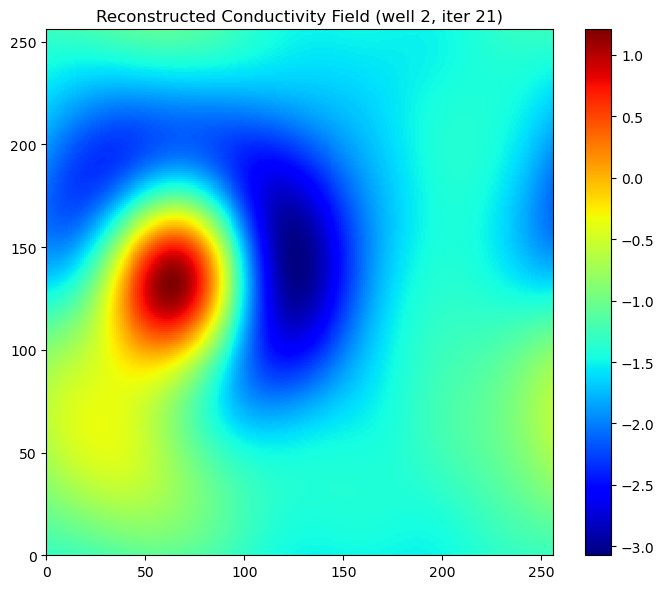

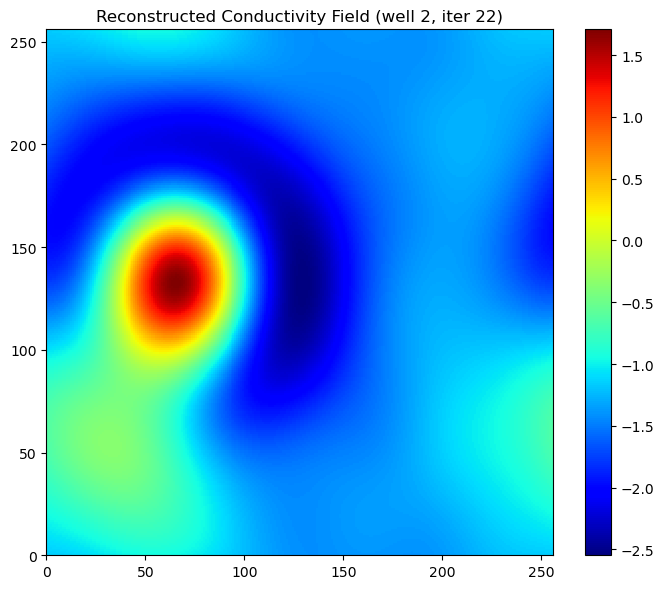

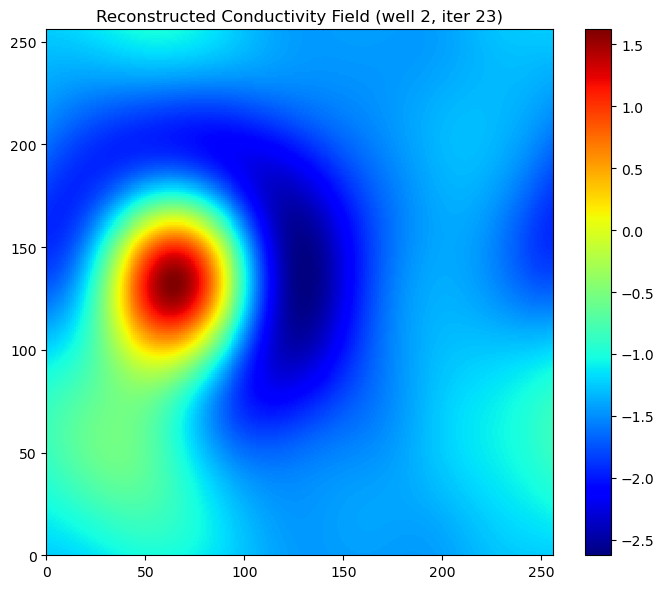

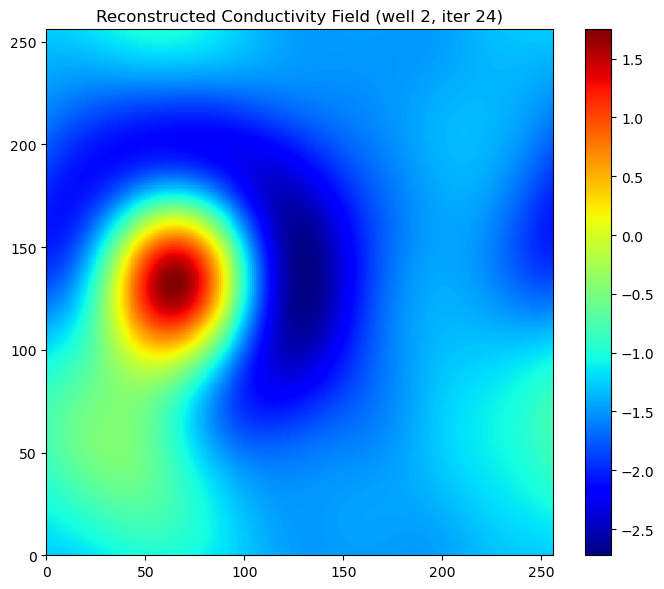

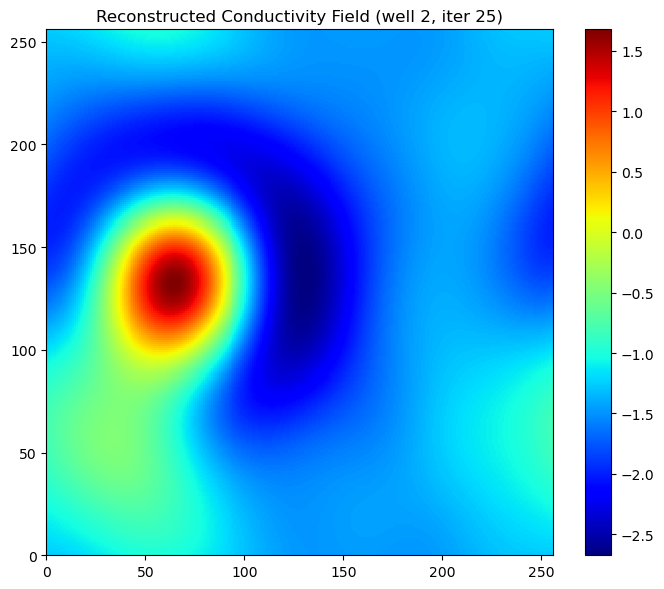

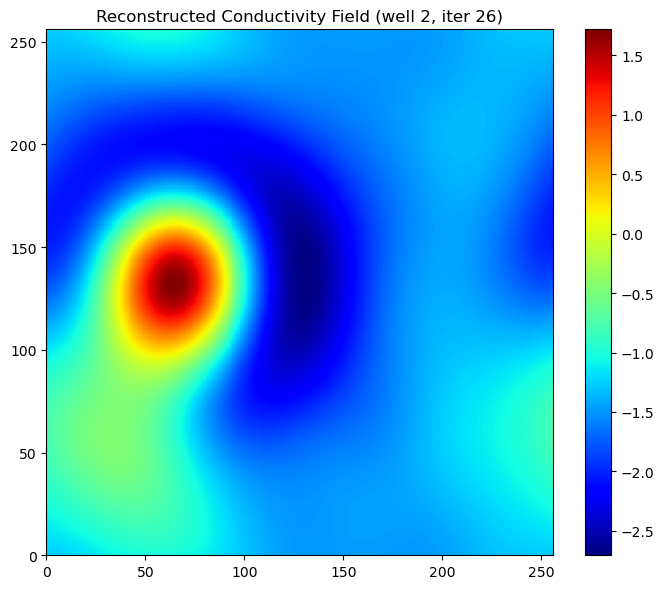

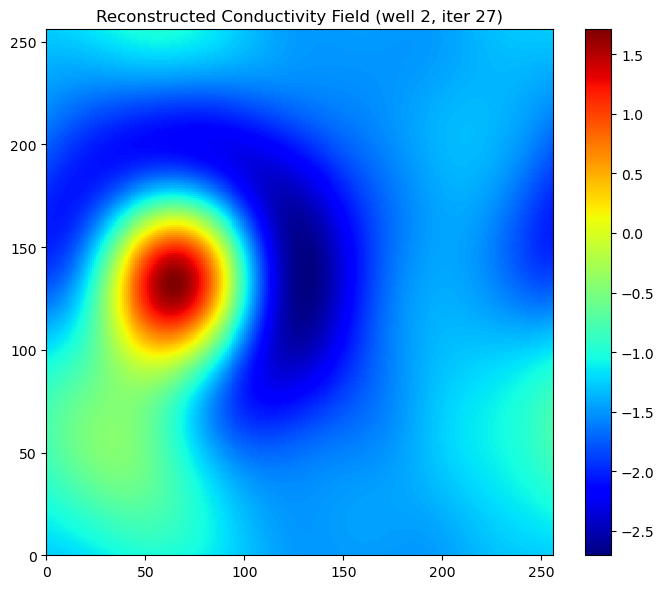

Iter  Lambda      Loss           Step Norm      Time (s)  
------------------------------------------------------------
1     1.00e-03    1.122260e+02   1.534453e+00   18.803    
2     1.00e-03    1.037404e+02   8.179660e-02   21.064    
3     1.00e-03    1.029841e+02   7.343303e-03   26.386    
4     6.89e-04    1.352836e+02   1.795803e-02   29.040    
5     6.89e-04    1.351057e+02   1.316614e-03   23.438    
6     6.89e-04    1.350327e+02   5.409023e-04   26.086    


KeyboardInterrupt: 

In [212]:
# iterate over the well nodes one by one, after each optimization, use the results as the initial guess for the next well node
b_prev = np.concatenate((np.zeros(k), np.array([beta])))
for k in range(len(pump_id_list)):
    y0 = transient_observation_operator(HT_transient_heads, well_nodes, pump_id_list=[k], timesteps=np.arange(0, 10, 1))
    y_obs, obv_error = add_noise(y0, noise_level=0.05)
    partial_well_nodes = [well_nodes[idx] for idx in [k]]
    b, opt_history = gauss_newton_dynamic_lambda(
        lambda b: transient_forward_model(b, V.T, Q, partial_well_nodes, well_nodes, dt, t_max, [], [], initial_head),
        b0=b_prev,
        y_obs=y_obs,
        lam_init=1e-3,
        max_iter=10,
        tol=1e-5,
        history=initial_history,
        adaptive_lambda=False,
        anneal_lambda=True,
        min_lambda=1e-5,
        json_file=f"{DEFAULT_FIG_DIR}/history_well_{i}.json"
    )
    b_prev = b

    # Save reconstructed fields for each iteration at each pumping well
    reconstructed_fields = []
    for i, (alpha, mu) in enumerate(zip(opt_history['alpha'], opt_history['mu'])):
        reconstructed_field = (V.T @ alpha[:, np.newaxis]).squeeze() + mu
        reconstructed_fields.append(reconstructed_field.copy())
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.pcolormesh(reconstructed_field.reshape((nx, ny)), cmap='jet')
        fig.colorbar(im, ax=ax)
        ax.set_title(f'Reconstructed Conductivity Field (well {k}, iter {i})')
        plt.tight_layout()
        plt.show()
        plt.close(fig)
    # Optionally, save all reconstructed fields to disk as a numpy file
    np.save(f"{DEFAULT_FIG_DIR}/reconstructed_fields_well_{k}.npy", np.array(reconstructed_fields))


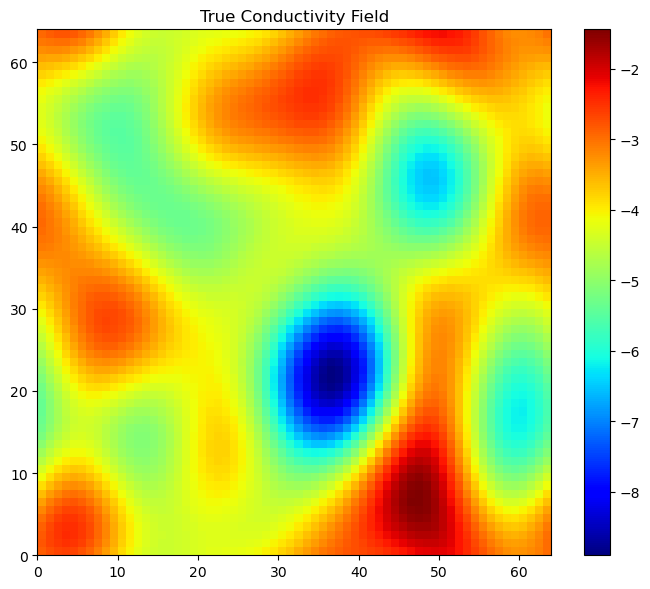

In [172]:
true_field = np.squeeze(V.T @ true_alpha[:, np.newaxis]) + true_mu
# plot and save the true field
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(true_field.reshape((nx, ny)), cmap='jet')
fig.colorbar(im, ax=ax)
ax.set_title('True Conductivity Field')
plt.tight_layout()
fig_path = f"{DEFAULT_FIG_DIR}/true_field.png"
fig.savefig(fig_path, dpi=100)
# fig.savefig(f"{DEFAULT_FIG_DIR}/conductivity_fields.png", dpi=300, bbox_inches='tight')

Conductivity Field Metrics:
L2 relative error: 0.5215133847227202
Accuracy: 0.1435546875
Heads Metrics:
MAE: 12.97272372629343 m
RMSE: 19.90167395225209 m
MSE: 396.07662610174935 m^2
L2 relative error: 0.9180765925478626
Heads Metrics:
MAE: 18.53614802584388 m
RMSE: 20.183864451725842 m
MSE: 407.3883842056421 m^2
L2 relative error: 0.8624803763001663


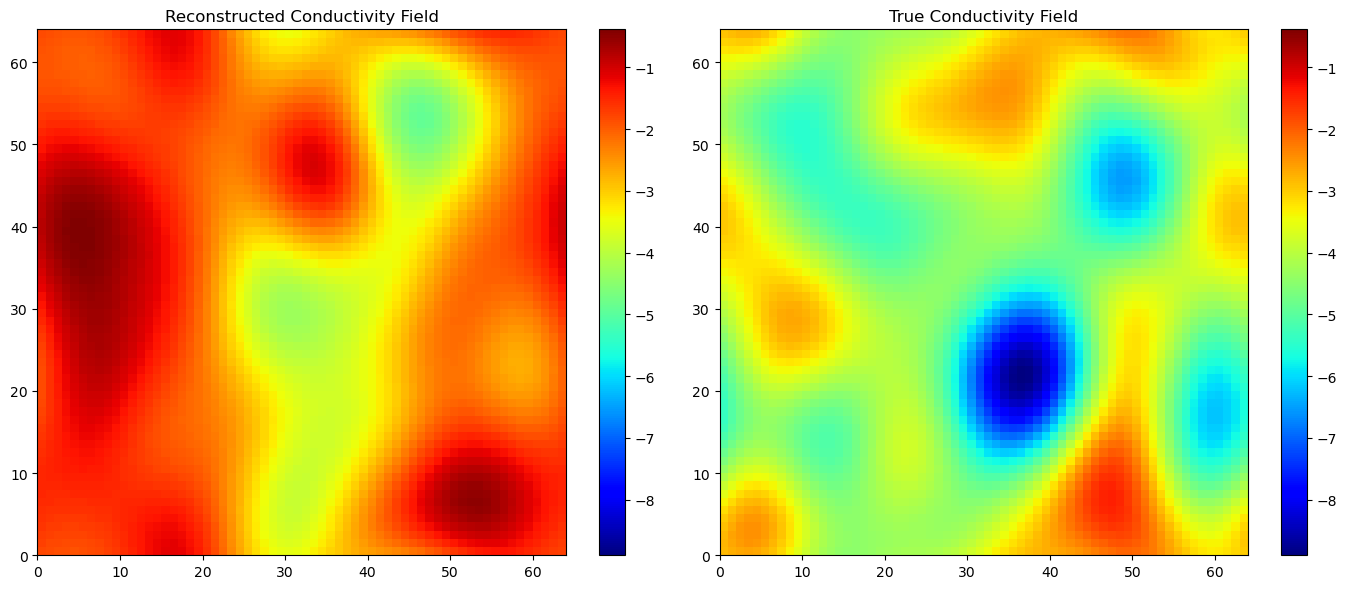

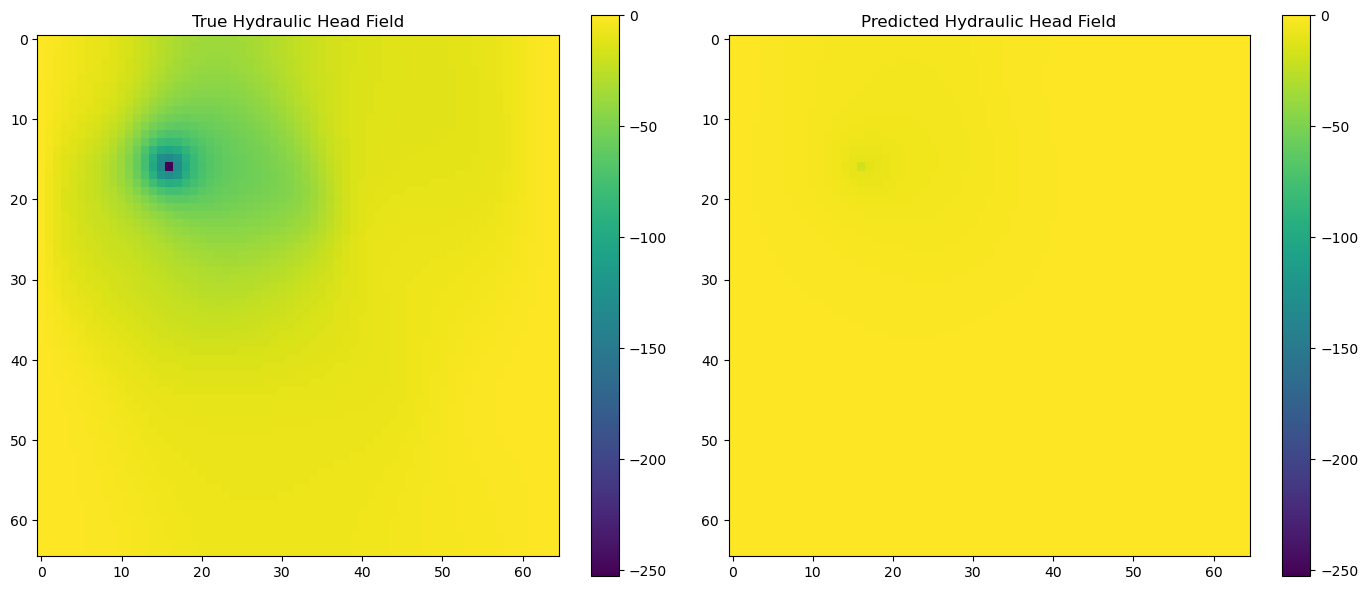

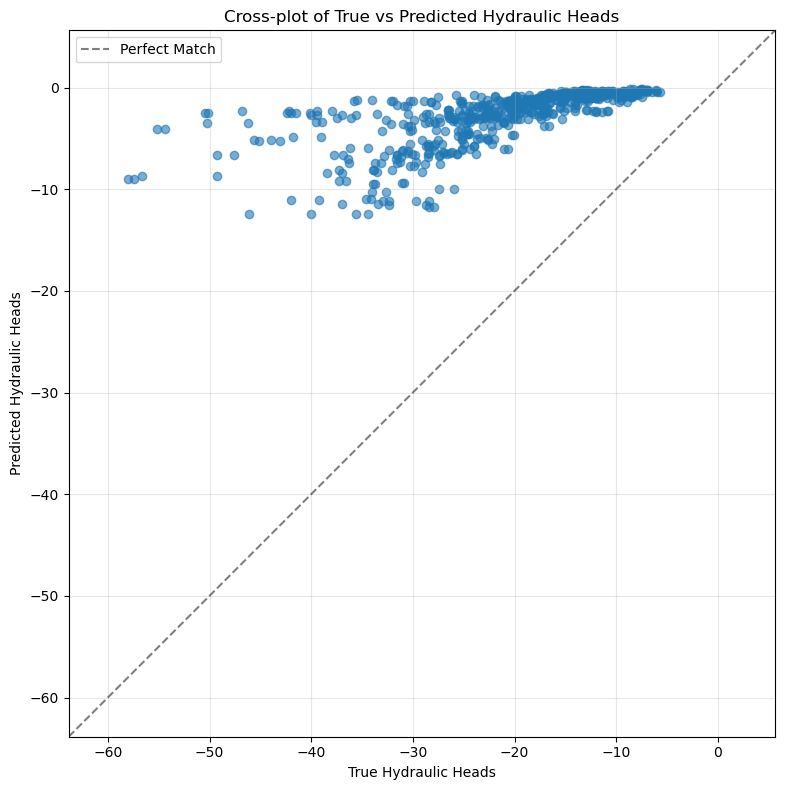

In [176]:

# Reconstruct the field
reconstructed_field = np.squeeze(V.T @ predicted_alpha[:, np.newaxis],axis=1) + predicted_mu
true_field = np.squeeze(V.T @ true_alpha[:, np.newaxis]) + true_mu

# Compute the conductivity metrics
conductivity_metrics(true_field, reconstructed_field)

# Plot the solution
fig1 = plot_conductivity_fields(reconstructed_field, true_field, nx, ny)

# compute the head fields
true_head_field = hydraulic_tomography(np.exp(true_field), well_nodes, Q)
predicted_head_field = hydraulic_tomography(np.exp(reconstructed_field), well_nodes, Q)

# Plot the head fields
pump_id = 0 # 0, 1, 2, 3, 4 
fig3 = plot_head_fields(true_head_field[pump_id].reshape((nx+1, ny+1)), predicted_head_field[pump_id].reshape((nx+1, ny+1)))

# compute the head metrics
mae, rmse, mse, l2_relative_error = head_metrics(true_head_field[pump_id], predicted_head_field[pump_id])

# Extract the true and predicted heads
true_heads = history['y_obs']
predicted_heads = observation_operator(predicted_head_field, well_nodes)
mae, rmse, mse, l2_relative_error = head_metrics(true_heads, predicted_heads)

# Plot the heads comparison
fig4 = plot_observations_vs_predictions(true_heads, predicted_heads)